In [1]:
import os

path = r"C:\Users\DANGER\.cache\kagglehub\datasets\vinayak123tyagi\bearing-dataset\versions\1"

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:  # afficher 5 fichiers max par dossier
            print(f"{indent}  {f}")

1/
  Readme Document for IMS Bearing Data.pdf
  1st_test/
    1st_test/
  2nd_test/
    2nd_test/
  3rd_test/
    4th_test/
      txt/


In [2]:
import os

test2_path = r"C:\Users\DANGER\.cache\kagglehub\datasets\vinayak123tyagi\bearing-dataset\versions\1\2nd_test\2nd_test"

fichiers = sorted(os.listdir(test2_path))
print(f"Nombre de fichiers : {len(fichiers)}")
print("\nPremiers fichiers :")
for f in fichiers[:5]:
    print(f)
print("\nDerniers fichiers :")
for f in fichiers[-5:]:
    print(f)

Nombre de fichiers : 984

Premiers fichiers :
2004.02.12.10.32.39
2004.02.12.10.42.39
2004.02.12.10.52.39
2004.02.12.11.02.39
2004.02.12.11.12.39

Derniers fichiers :
2004.02.19.05.42.39
2004.02.19.05.52.39
2004.02.19.06.02.39
2004.02.19.06.12.39
2004.02.19.06.22.39


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

test2_path = r"C:\Users\DANGER\.cache\kagglehub\datasets\vinayak123tyagi\bearing-dataset\versions\1\2nd_test\2nd_test"

# Charger tous les fichiers
records = []
fichiers = sorted(os.listdir(test2_path))

for fname in fichiers:
    fpath = os.path.join(test2_path, fname)
    try:
        # Chaque fichier = 4 colonnes (4 capteurs), séparées par des tabs
        data = pd.read_csv(fpath, sep="\t", header=None)
        data.columns = ["b1", "b2", "b3", "b4"]
        
        # Extraire les features statistiques pour chaque capteur
        row = {"timestamp": pd.to_datetime(fname, format="%Y.%m.%d.%H.%M.%S")}
        for col in ["b1", "b2", "b3", "b4"]:
            row[f"{col}_rms"]      = np.sqrt(np.mean(data[col]**2))        # vibration globale
            row[f"{col}_std"]      = data[col].std()                        # variabilité
            row[f"{col}_peak"]     = data[col].abs().max()                  # pic max
            row[f"{col}_kurtosis"] = data[col].kurtosis()                   # chocs (pannes)
        records.append(row)
    except Exception as e:
        print(f"Erreur {fname}: {e}")

df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)
print(f"Dataset chargé : {df.shape}")
print(df.head(3).to_string())

Dataset chargé : (984, 17)
            timestamp    b1_rms    b1_std  b1_peak  b1_kurtosis    b2_rms    b2_std  b2_peak  b2_kurtosis    b3_rms    b3_std  b3_peak  b3_kurtosis    b4_rms    b4_std  b4_peak  b4_kurtosis
0 2004-02-12 10:32:39  0.074179  0.073477    0.454     0.629209  0.090944  0.090056    0.513     0.507217  0.109404  0.108436    1.023     3.214152  0.054103  0.053168    0.264     0.066268
1 2004-02-12 10:42:39  0.075382  0.075340    0.388     0.648742  0.093419  0.093386    0.481     0.253369  0.109817  0.109792    0.752     1.395884  0.056101  0.055974    0.249     0.107859
2 2004-02-12 10:52:39  0.076230  0.076191    0.503     0.513894  0.093718  0.093705    0.503     0.311158  0.109861  0.109852    0.933     2.640886  0.056145  0.056038    0.354     0.257592


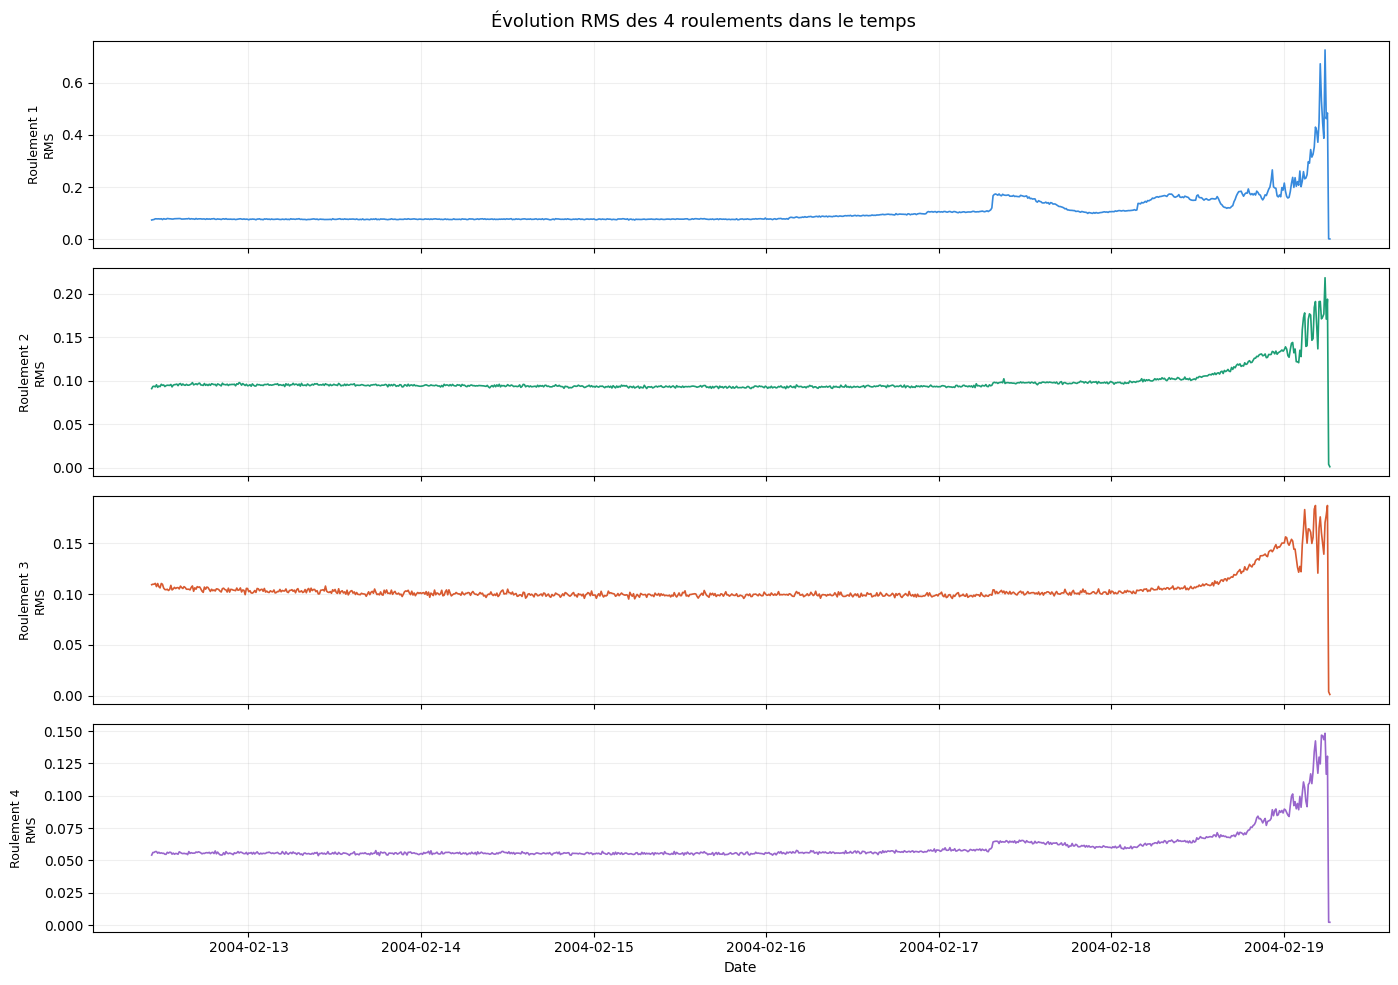

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Évolution RMS des 4 roulements dans le temps", fontsize=13)

colors = ["#378ADD", "#1D9E75", "#D85A30", "#9966CC"]
for i, (ax, color) in enumerate(zip(axes, colors), 1):
    ax.plot(df["timestamp"], df[f"b{i}_rms"], color=color, lw=1.2)
    ax.set_ylabel(f"Roulement {i}\nRMS", fontsize=9)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()
# Tu verras le roulement 1 exploser vers la fin → c'est la panne !

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Features utilisées
features = [c for c in df.columns if c != "timestamp"]

X = df[features].values

# On entraîne sur les 500 premiers fichiers (période saine)
X_train = X[:500]
X_all   = X

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled   = scaler.transform(X_all)

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled)

# Score d'anomalie sur tout le dataset
df["anomaly_score"] = -model.score_samples(X_all_scaled)
df["anomalie"]      = model.predict(X_all_scaled)
df["anomalie"]      = df["anomalie"].map({1: 0, -1: 1})

print(f"Anomalies détectées : {df['anomalie'].sum()} / {len(df)}")

Anomalies détectées : 431 / 984


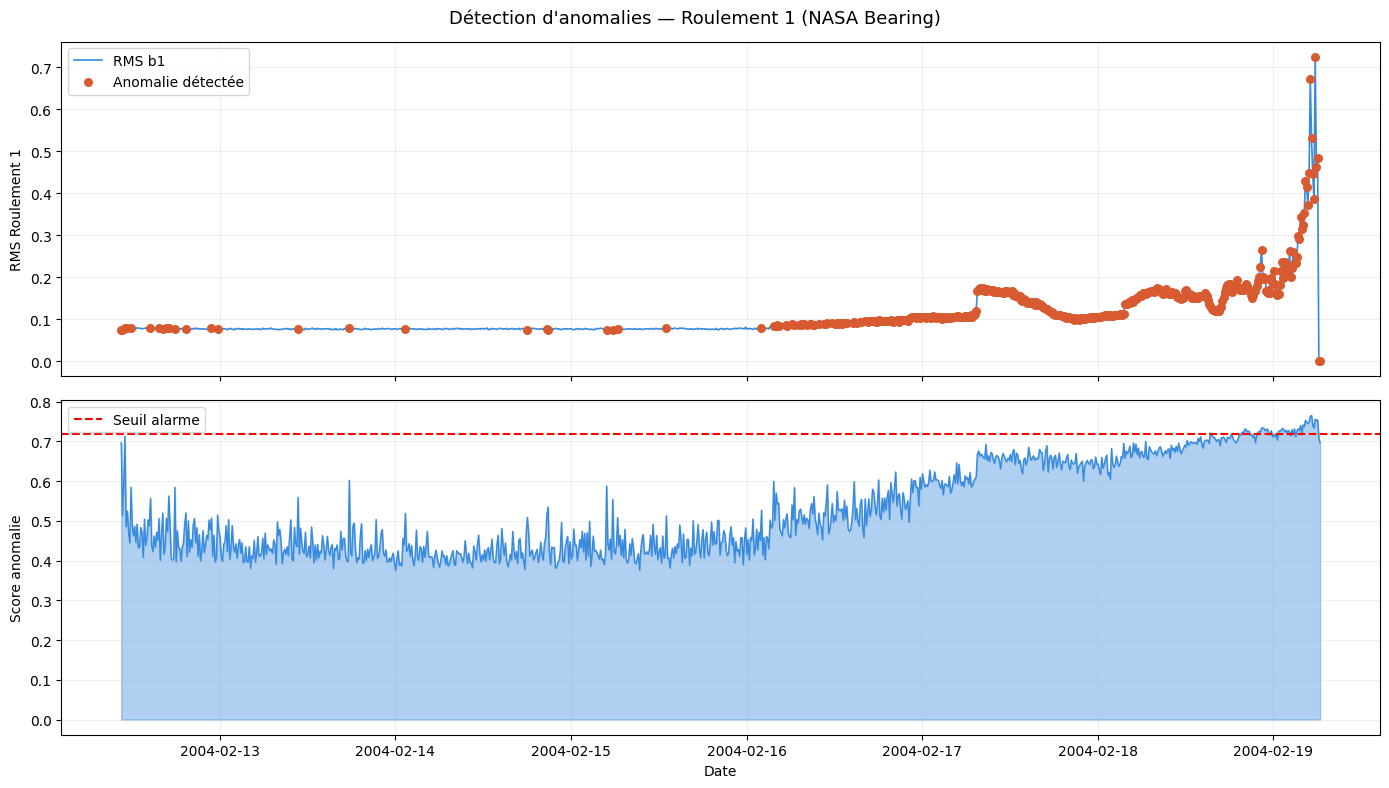

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Détection d'anomalies — Roulement 1 (NASA Bearing)", fontsize=13)

# Signal RMS roulement 1
ax = axes[0]
ax.plot(df["timestamp"], df["b1_rms"], color="#378ADD", lw=1.2, label="RMS b1")
anomalies = df[df["anomalie"] == 1]
ax.scatter(anomalies["timestamp"], anomalies["b1_rms"],
           color="#D85A30", s=30, zorder=5, label="Anomalie détectée")
ax.set_ylabel("RMS Roulement 1")
ax.legend()
ax.grid(True, alpha=0.2)

# Score d'anomalie
ax = axes[1]
ax.fill_between(df["timestamp"], df["anomaly_score"],
                alpha=0.4, color="#378ADD")
ax.plot(df["timestamp"], df["anomaly_score"], color="#378ADD", lw=1)
ax.axhline(np.percentile(df["anomaly_score"], 95),
           color="red", lw=1.5, linestyle="--", label="Seuil alarme")
ax.set_ylabel("Score anomalie")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()